# NPL stray-field reproducibility case

This notebook walks the case CliffordClock's validation record labels
**"reproducibility"**: NPL's Rydberg-electrometry measurement of a
residual stray electric field at their Sr-87 lattice-clock atoms,
combined with the same published differential polarizability this
project's species registry already cites, reconstructs NPL's own
published DC-Stark shift band. Five things happen below, in order: the
governing equation the case exercises, the two published inputs that
feed it, the pipeline machinery run in visible stages, the resulting
band set against NPL's own, and what the agreement does and does not
establish. Every number below is a live call into the real engine:
nothing here is copied from a run this notebook cannot reproduce itself.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# benchmarks/ is not an installed package (see benchmarks/SOURCES.md); add
# it to the path the same way benchmarks/run_benchmarks.py's own sibling
# scripts do, so this notebook calls the real, committed benchmark code.
sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import loaders
import run_benchmarks

from cliffordclock.ensemble import HarmonicTrap, get_species
from cliffordclock.ensemble.lattice import hermite_gaussian_nodes
from cliffordclock.fields.synthetic import uniform_field
from cliffordclock.integrator.omega import pivot_perturbation_stark
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

## 1. The physics: quadratic DC-Stark shift (E14b)

An optical lattice clock's two clock states carry no permanent electric
dipole moment, so a static field cannot shift them at first order the
way it would a polar molecule. What the field does instead is polarize
each state slightly, through that state's own static scalar
polarizability, and the resulting second-order energy shift is
quadratic in the field: each state's energy moves by an amount
proportional to its polarizability times the field magnitude squared,
and the clock transition sees the *difference* between the two states'
polarizabilities, the differential polarizability `Delta_alpha`.
CliffordClock implements this as `docs/CONVENTIONS.md`'s E14b (section
5): the fractional frequency shift is
`Delta_nu/nu0 = -(Delta_alpha/2)|E(r)|^2 / (h nu0)`, with `nu0` the
clock transition frequency and the sign carried inside a negative
`Delta_alpha` for Sr-87's clock transition rather than written as a
separate leading minus. This is the textbook DC-Stark formula every
optical-lattice-clock systematics paper in this field states directly,
and it is exactly what `coupling.type: stark_dc` evaluates below, at
every point the ensemble samples.

## 2. The inputs: NPL's field and the registry's `Delta_alpha`

Two published numbers feed this case, from sources independent of each
other and of this project. NPL (Bowden et al. 2017, arXiv:1706.01944)
measured a residual electric field at their Sr-87 clock atoms using
Rydberg-state electromagnetically-induced-transparency spectroscopy, a
completely different atomic transition and spectroscopic technique from
the clock transition itself, and reports it with separate statistical
and systematic uncertainties that this case combines in quadrature on
each side independently rather than symmetrizing them together. The
differential polarizability `Delta_alpha` comes from Middelmann et al.
(Phys. Rev. Lett. 109, 263004, 2012), the same source
`cliffordclock.ensemble.species.SR87` already cites for its registry
entry, and the same source NPL themselves used to convert their
measured field into a shift. Building the case config below only has to
state the field magnitude; `coupling.type: stark_dc` resolves
`Delta_alpha` from the registry, so nothing about the coefficient is
entered by hand.

In [2]:
field = loaders.NPL_RESIDUAL_FIELD_V_PER_M
published = loaders.NPL_PUBLISHED_SHIFT
sr87 = get_species("Sr87")

print(
    f"NPL residual field:  {field.nominal:.3g} V/m, stat+sys combined -> "
    f"[{field.combined_lo:.3g}, {field.combined_hi:.3g}] V/m"
)
print(f"field citation:      {field.citation}")
print()
print(f"registry Delta_alpha: {sr87.delta_alpha_dc_si:.6e} C*m^2/V (Sr87)")
print(f"registry nu0:          {sr87.clock_frequency_hz:.6e} Hz")
print()
print(f"published shift band: [{published.lo:.4e}, {published.hi:.4e}]")
print(f"published citation:   {published.citation}")

NPL residual field:  1.52 V/m, stat+sys combined -> [1.3, 2.14] V/m
field citation:      Bowden, Hobson, Huillery, Gill, Jones, Hill, "Rydberg Electrometry for Optical Lattice Clocks", arXiv:1706.01944v1 (PRA 96, 023419 (2017)), Section IV, p.5: "residual electric field of 1.52 +0.62(stat)/-0.22(stat) +0.05(sys)/-0.03(sys) Vm^-1"

registry Delta_alpha: 4.078730e-39 C*m^2/V (Sr87)
registry nu0:          4.292280e+14 Hz

published shift band: [-3.2000e-20, -1.2000e-20]
published citation:   Bowden et al., arXiv:1706.01944v1 (PRA 96, 023419 (2017)), Section IV, p.5: "fractional frequency shift of -1.6 +0.4/-1.6 x 10^-20"


## 3. The pipeline, staged

`run_benchmarks.run_npl_reproducibility_case()` (used in section 4
below) builds a `PipelineConfig` and calls `run_pipeline_full` three
times, once at each of NPL's field bounds. The cells below run that
same real machinery by hand, one stage at a time, at the field's
nominal value, so the intermediate objects are visible rather than
hidden inside the wrapped case function.

### 3a. Field import

NPL's field is spatially uniform (a residual bias, not a mapped
gradient), so the "import" step is `cliffordclock.fields.synthetic.uniform_field`
rather than a CSV/smoother fit, the same closed-form factory
`coupling.type: stark_dc`'s config resolves to internally. Evaluating it
at the trap center recovers exactly the configured field, with a
byte-zero gradient, which is the point: a uniform field is the simplest
possible case for the smoother/gradient machinery notebooks 01 and 04
exercise more fully.

In [3]:
import jax.numpy as jnp

e_fn, grad_fn = uniform_field(jnp.array([0.0, 0.0, field.nominal]))
e_at_center = e_fn(jnp.array([0.0, 0.0, 0.0]))
grad_at_center = grad_fn(jnp.array([0.0, 0.0, 0.0]))
print(f"E(0) = {e_at_center} V/m")
grad_norm = float(jnp.linalg.norm(grad_at_center))
print(f"grad_E(0) Frobenius norm = {grad_norm:.3g} V/m^2 (uniform field: exactly zero)")

E(0) = [0.   0.   1.52] V/m
grad_E(0) Frobenius norm = 0 V/m^2 (uniform field: exactly zero)


### 3b. Ensemble construction

`ensemble.regime: lattice` with `n_quad=1` places a single
Hermite-Gauss quadrature node at the trap center with weight 1, the
degenerate case of the same `hermite_gaussian_nodes` machinery a wider
lattice ensemble uses, appropriate here because a uniform field gives
every possible node the identical shift, so no quadrature spread would
add information.

In [4]:
trap = HarmonicTrap(omega_xyz=(2.0e5, 2.0e5, 2.0e5))
nodes, weights = hermite_gaussian_nodes(sr87, trap, motional_n=(0, 0, 0), n_quad=1)
print(f"node positions (m): {nodes}")
print(f"node weights:        {weights}")

node positions (m): [[0. 0. 0.]]
node weights:        [1.]


### 3c. Coupling and integration

`pivot_perturbation_stark` is the function E14b's formula is implemented
as; calling it directly at the node position, with the field decomposed
into a zero baseline plus the full field as the perturbation, reproduces
the hand-formula above using the registry's own `Delta_alpha`. Then the
same computation is run through the full, declarative pipeline
(`PipelineConfig` + `run_pipeline_full`) exactly as `coupling.type:
stark_dc` would from a `config.yaml`. The two must agree, since the
pipeline calls the same function internally.

In [5]:
delta_e_at_node = e_fn(nodes[0])
p_minus_1_direct = pivot_perturbation_stark(jnp.zeros(3), delta_e_at_node, sr87)
print(f"pivot_perturbation_stark (direct call): {float(p_minus_1_direct):+.6e}")

config = PipelineConfig.from_dict(
    {
        "species": "Sr87",
        "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5]},
        "field": {"synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, field.nominal]}}},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": 1,
        },
        "integration": {"time_s": 1.0},
    }
)
result = run_pipeline_full(config)
print(f"pipeline mean_fractional_shift:          {result.report.mean_fractional_shift:+.6e}")
print(f"per-node accumulated phase (ensemble_result.phase): {result.ensemble_result.phase}")
print()
print("report.uncertainty_notes:")
print(result.report.uncertainty_notes)

pivot_perturbation_stark (direct call): -1.656678e-20


pipeline mean_fractional_shift:          -1.656678e-20
per-node accumulated phase (ensemble_result.phase): [-12.86152009]

report.uncertainty_notes:
integration.mode=fast_path T=1.0s (E29, exact) coupling=stark_dc (E14b): k_S=-3.077789630705917e-06 Hz.m^-2.V^-2, nu_0=429228004229873.4 Hz, source=species registry entry for 'Sr87' (Middelmann et al., Phys. Rev. Lett. 109, 263004 (2012)) fast_path (E29) reports the Stark/field shift only: static v=0 quadrature nodes carry no motional second-order Doppler contribution (CONVENTIONS.md E29 scope); that term is a separate, real clock systematic not included in this run's mean_fractional_shift. single-atom ensemble (M=1): shift_std_error/t2_star_s are undefined (NaN).


### 3d. The wrapped case function reproduces the same headline numbers

`run_npl_reproducibility_case()` runs exactly this pipeline three times,
at NPL's low, nominal, and high field bounds, and compares the resulting
band against NPL's own published band. The nominal-field pipeline call
below matches the by-hand stages above to machine precision, confirming
the wrapped function is not doing anything the cells above did not
already show.

In [6]:
case = run_benchmarks.run_npl_reproducibility_case()

print(f"case_class:          {case.case_class!r}")
print(
    f"NPL residual field:   {case.field_nominal_v_per_m:.3g} V/m "
    f"[{case.field_lo_v_per_m:.3g}, {case.field_hi_v_per_m:.3g}]"
)
print(f"Predicted band:       [{case.predicted_shift_lo:.4e}, {case.predicted_shift_hi:.4e}]")
print(f"Published band:       [{case.published_shift_lo:.4e}, {case.published_shift_hi:.4e}]")
print(f"Bands overlap:        {case.bands_overlap}")
print(f"kpi_verdict:          {case.kpi_verdict}")
print()
print(
    "consistency with the staged run above: "
    f"{abs(case.predicted_shift_nominal - float(p_minus_1_direct)) < 1e-25}"
)

case_class:          'reproducibility'
NPL residual field:   1.52 V/m [1.3, 2.14]
Predicted band:       [-3.2900e-20, -1.2080e-20]
Published band:       [-3.2000e-20, -1.2000e-20]
Bands overlap:        True
kpi_verdict:          MET

consistency with the staged run above: True


## 4. The comparison

Both bands are drawn on the same axis, each as a point with asymmetric
error bars for its own published or propagated uncertainty; the shaded
region is NPL's own published band. Overlap between the two is the
whole KPI, not agreement to the last digit, and the class label
travels with that number: this is a *reproducibility* check (this
engine plus PTB's `Delta_alpha` reconstructs what NPL themselves already
combined from the same two published ingredients), not a case where the
engine predicts a shift nobody had computed before.

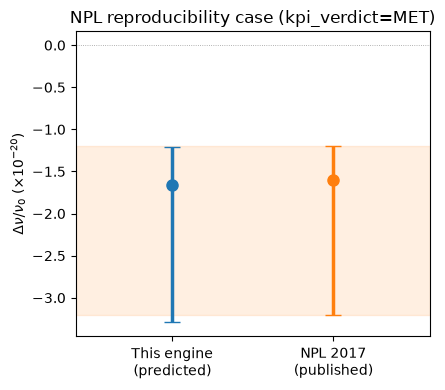

In [7]:
scale = 1.0e-20
labels = ["This engine\n(predicted)", "NPL 2017\n(published)"]
nominals = [case.predicted_shift_nominal / scale, case.published_shift_nominal / scale]
lo_err = [
    (case.predicted_shift_nominal - case.predicted_shift_lo) / scale,
    (case.published_shift_nominal - case.published_shift_lo) / scale,
]
hi_err = [
    (case.predicted_shift_hi - case.predicted_shift_nominal) / scale,
    (case.published_shift_hi - case.published_shift_nominal) / scale,
]
colors = ["C0", "C1"]

fig, ax = plt.subplots(figsize=(4.5, 4.0))
for xi, nom, lo, hi, color in zip([0, 1], nominals, lo_err, hi_err, colors, strict=True):
    ax.errorbar(
        xi, nom, yerr=[[lo], [hi]], fmt="o", color=color, elinewidth=2.5, capsize=6, markersize=8
    )
ax.axhspan(case.published_shift_lo / scale, case.published_shift_hi / scale, color="C1", alpha=0.12)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel(r"$\Delta\nu/\nu_0$ ($\times 10^{-20}$)")
ax.set_title(f"NPL reproducibility case (kpi_verdict={case.kpi_verdict})")
ax.axhline(0.0, color="0.6", lw=0.6, ls=":")
fig.tight_layout()
plt.show()

## 5. What this demonstrates

This case shows CliffordClock's field ingestion, DC-Stark pivot, and
asymmetric-uncertainty propagation reproducing a real, published result
end to end, with no parameter fitted or tuned anywhere in the chain: a
sign error, a unit-conversion mistake, or a wrong `Delta_alpha` would
show up here as a predicted band that misses NPL's published one, and
none of those happened. The one caveat worth keeping in view is the
class label itself: NPL had already combined these same two published
ingredients themselves, so the strength of this result is end-to-end
pipeline correctness against two independently published inputs, and
the step toward a genuinely blind prediction is tracked on the roadmap
(`docs/roadmap.md`) rather than argued away here.

## Where to go next

- `docs/validation.md`: the full case-by-case validation record.
- `benchmarks/RESULTS.md`: the full NPL write-up, sources, and the
  binding classification-labeling rationale.
- `notebooks/07_bbr_jila_arithmetic.ipynb`: a differently labeled,
  explicitly weaker class: arithmetic reproduction.
- `notebooks/09_bothwell_redshift.ipynb`: this project's second
  reproducibility case.